In [14]:
import torch
from torch import optim, nn, utils, Tensor
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
import torchvision
print(f"Torch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Torch version: 2.10.0
Torchvision version: 0.25.0
CUDA available: False


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# Data Loading

In [117]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, Subset

# 1. Define transformations for Grayscale images (1 channel)
# Augmentation for training
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]) # Simplified for grayscale
])

# Standard transforms for validation/testing
val_test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# 2. Create datasets and split indices
dataset_path = 'dataset/anuka1200'
dataset = ImageFolder(root=dataset_path, transform=val_test_transforms)

# Split indices
total_size = len(dataset)
indices = list(range(total_size))
train_indices, val_indices, test_indices = random_split(indices, [0.8, 0.1, 0.1], 
                                                        generator=torch.Generator().manual_seed(42))

# 3. Create subsets with respective transforms
train_dataset = Subset(ImageFolder(root=dataset_path, transform=train_transforms), train_indices)
val_dataset = Subset(dataset, val_indices)
test_dataset = Subset(dataset, test_indices)


# 4. Access classes and counts
print(f"Classes found: {dataset.classes}")
print(f"Number of images: {len(dataset)}")
print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(test_dataset)}")

# 5. Create DataLoaders
batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Test loading one batch
images, labels = next(iter(train_dataloader))
print(f"Batch images shape: {images.shape}")
print(f"Batch labels: {labels}")

Classes found: ['Tipo A: Kunzea', 'Tipo B: Lepto']
Number of images: 2400
Train size: 1920, Val size: 240, Test size: 240
Batch images shape: torch.Size([32, 1, 224, 224])
Batch labels: tensor([1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,
        1, 1, 1, 1, 1, 0, 1, 0])


In [116]:
for i in train_dataloader:
    print(len(i), i[0].shape, i[1].shape)
    print(i[1])
    break

2 torch.Size([32, 1, 224, 224]) torch.Size([32])
tensor([0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
        0, 0, 1, 1, 0, 0, 1, 0])


# Visualization

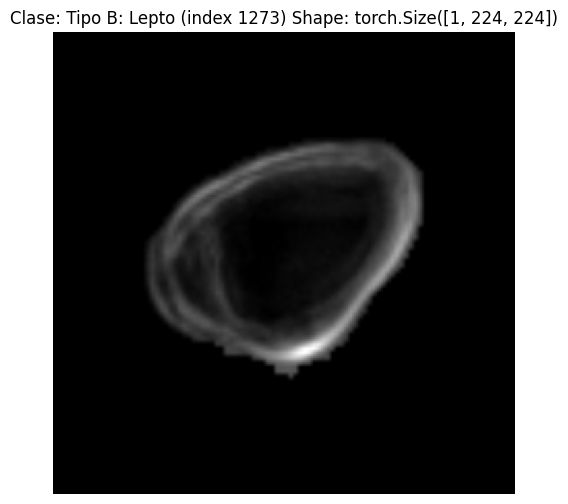

In [5]:
import matplotlib.pyplot as plt
import random
import numpy as np

# 1. Select a random index
idx = random.randint(0, len(dataset) - 1)
image, label = dataset[idx]

# 2. Un-normalize the image for visualization
mean = 0.5
std = 0.5
image_vis = image.numpy().squeeze() # (1, 224, 224) -> (224, 224)
image_vis = std * image_vis + mean
image_vis = np.clip(image_vis, 0, 1)

# 3. Display
plt.figure(figsize=(6, 6))
plt.imshow(image_vis, cmap='gray')
plt.title(f"Clase: {dataset.classes[label]} (index {idx}) Shape: {image.shape}")
plt.axis('off')
plt.show()

# Entrenamiento

## Definición del modelo.
Usaremos Pytorch Lightning, un wrapper de PyTorch que nos facilita el entrenamiento y la organización del código. Para ello, definiremos una clase que herede de `pl.LightningModule` y que implemente los métodos necesarios para el entrenamiento, validación y test.

```python

In [ ]:
class RedNeuronal(L.LightningModule):
    def __init__(self, model, is_cnn=False):
        super().__init__()
        self.model = model
        self.loss_fn = nn.BCEWithLogitsLoss()
        self.is_cnn = is_cnn

    def training_step(self, batch, batch_idx):
        x, y = batch
        if not self.is_cnn:
            x = x.view(x.size(0), -1)  
        logits = self.model(x).squeeze(dim=1)
        y = y.float()
        loss = self.loss_fn(logits, y)
        accuracy = ((logits > 0.5).float() == y).float().mean()
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_accuracy',accuracy, prog_bar=True)
        return loss
    
    def test_step(self, batch, batch_idx):
        x, y = batch
        if not self.is_cnn:
            x = x.view(x.size(0), -1)  
        logits = self.model(x).squeeze(dim=1)
        y = y.float()
        loss = self.loss_fn(logits, y)
        accuracy = ((logits > 0.5).float() == y).float().mean()
        self.log('test_loss', loss, prog_bar=True)
        self.log('test_accuracy', accuracy, prog_bar=True)

    def validation_step(self, batch, batch_idx):    
        x, y = batch

        if not self.is_cnn:
            x = x.view(x.size(0), -1)  
        logits = self.model(x).squeeze(dim=1)
        y = y.float()
        loss = self.loss_fn(logits, y)
        accuracy = ((logits > 0.5).float() == y).float().mean()
        self.log('val_accuracy', accuracy, prog_bar=True)
        self.log('val_loss', loss, prog_bar=True)

    def configure_optimizers(self)[]:
        optimizer = optim.Adam(self.parameters(), lr=1e-5)
        return optimizer

In [ ]:
from lightning.pytorch.loggers import CSVLogger

# Configura el logger para que guarde en un CSV
logger = CSVLogger("logs", name="mi_experimento")
from lightning.pytorch.loggers import TensorBoardLogger



## Modelo Red Neuronal Unicapa

In [ ]:
trainer_rl = L.Trainer(limit_train_batches=100, max_epochs=3, callbacks=[EarlyStopping(monitor="val_loss", mode="min")], )
modelo_rl = nn.Sequential(nn.Linear(224 * 224, 16), nn.ReLU(), nn.Linear(16, 1))
modelo_rl = RedNeuronal(modelo_rl, False)
trainer_rl.fit(model=modelo_rl, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Sequential        │  802 K │ train │     0 │
│ 1 │ loss_fn │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴─────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 802 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 802 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/diego/.pyenv/versions/redes_neuronales/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:2
1: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

/Users/diego/.pyenv/versions/redes_neuronales/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/dat
a_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/Users/diego/.pyenv/versions/redes_neuronales/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/dat
a_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider 
increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=3` reached.


In [134]:
# Acceder al diccionario de estados
pesos = modelo_rl.state_dict()

# Ver los nombres de las capas y la forma de los tensores de pesos
for nombre, tensor in pesos.items():
    print(f"Capa: {nombre} | Tamaño: {tensor.size()}")
    print(tensor[:3]) # Descomenta para ver los números reales
    # print(tensor) # Descomenta para ver los números reales


Capa: model.0.weight | Tamaño: torch.Size([16, 50176])
tensor([[-4.2153e-03, -3.2269e-03, -2.0069e-03,  ..., -3.8103e-03,
         -3.9019e-03,  3.5696e-03],
        [ 3.5629e-03, -7.2928e-04, -3.0353e-04,  ...,  2.6619e-03,
          9.2860e-04,  4.2044e-03],
        [-8.1005e-05, -2.1118e-03,  3.5873e-03,  ...,  2.6165e-03,
         -2.7634e-03, -2.2467e-03]])
Capa: model.0.bias | Tamaño: torch.Size([16])
tensor([2.5936e-03, 3.2501e-03, 2.8587e-05])
Capa: model.2.weight | Tamaño: torch.Size([1, 16])
tensor([[-0.1531,  0.2093,  0.0304,  0.2442,  0.0530, -0.1899,  0.1426, -0.1840,
          0.0806,  0.0742,  0.0203,  0.0868, -0.1251,  0.1709, -0.1070, -0.1186]])
Capa: model.2.bias | Tamaño: torch.Size([1])
tensor([0.0363])


## Modelo Red Neuronal Multicapa

In [ ]:
trainer_mc = L.Trainer(limit_train_batches=100, max_epochs=3, callbacks=[EarlyStopping(monitor="val_loss", mode="min")],  )
modelo_mc = nn.Sequential(nn.Linear(224 * 224, 128), nn.ReLU(), nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 2))
modelo_mc = RedNeuronal(modelo_mc, False)
trainer_mc.fit(model=modelo_mc, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

## Modelo CNN
Definimos un modelo CNN sencillo con dos capas convolucionales seguidas de una capa fully connected. Este modelo debería ser capaz de capturar características espaciales en las imágenes y mejorar el rendimiento en comparación con las redes completamente conectadas.

In [66]:
modelo_cnn = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(32 * 56 * 56, 16),
    nn.ReLU(),
    nn.Linear(16, 2)
)

modelo_cnn = RedNeuronal(modelo_cnn, True)

trainer = L.Trainer(limit_train_batches=100, max_epochs=10, callbacks=[EarlyStopping(monitor="val_loss", mode="min")], )
trainer.fit(model=modelo_cnn, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
trainer.test(model=modelo_cnn, dataloaders=test_dataloader)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Sequential       │  1.6 M │ train │     0 │
│ 1 │ loss_fn │ CrossEntropyLoss │      0 │ train │     0 │
└───┴─────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 1.6 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.6 M                                                                                                
Total estimated model params size (MB): 6                                                                          
Modules in train mode: 12                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/diego/.pyenv/versions/redes_neuronales/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:2
1: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

/Users/diego/.pyenv/versions/redes_neuronales/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/dat
a_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/Users/diego/.pyenv/versions/redes_neuronales/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/dat
a_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider 
increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/Users/diego/.pyenv/versions/redes_neuronales/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
